In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, GridSearchCV
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from xgboost                  import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [4]:
from google.colab import files
uploaded = files.upload()



Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [5]:
df = pd.read_csv("credit_risk_dataset.csv")
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (32581, 12)

Missing values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.info()
df.describe()
print("\nTarget distribution:")
print(df["loan_status"].value_counts())
print(f"Default rate: {df['loan_status'].mean():.1%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Target distribution:
loan_stat

In [7]:
# loan_int_rate and person_emp_length have missing values
df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)
df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)

# Remove unrealistic ages (outliers)
df = df[df["person_age"] < 80]

print("Shape after cleaning:", df.shape)
print("Missing values remaining:\n", df.isnull().sum())

Shape after cleaning: (32573, 12)
Missing values remaining:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


/tmp/ipykernel_574/3774136796.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)
/tmp/ipykernel_574/3774136796.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

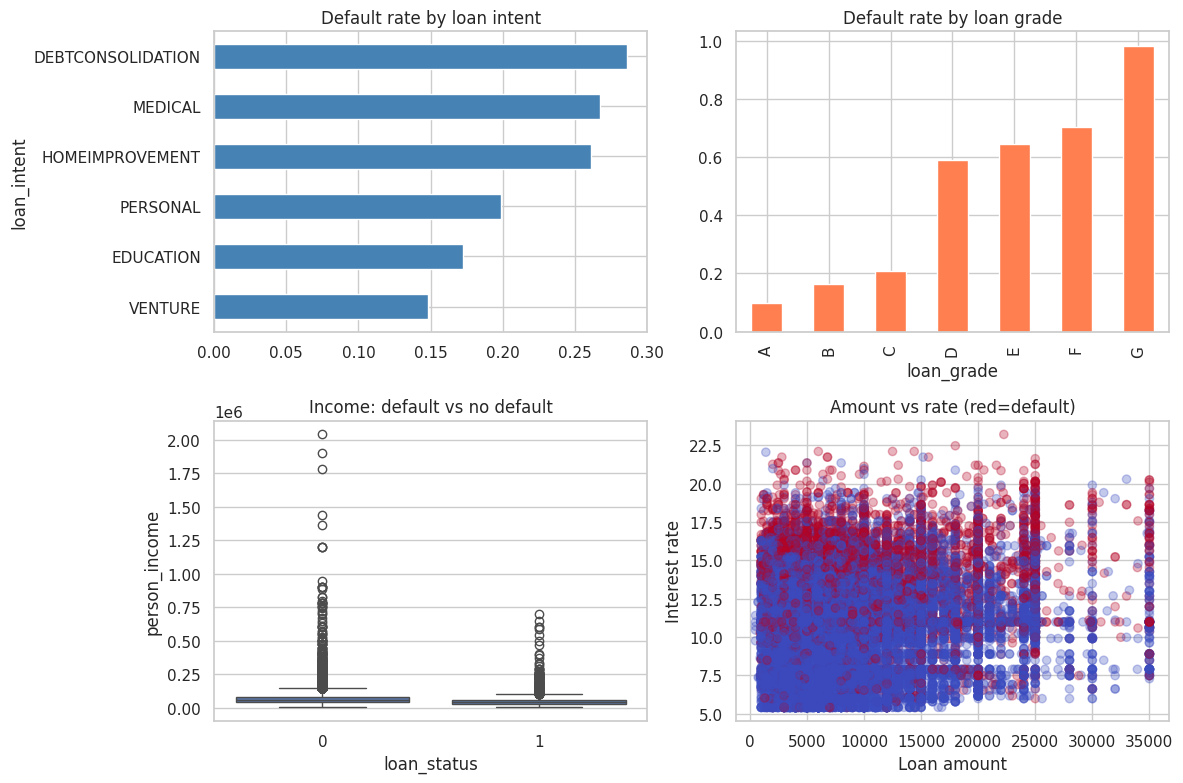

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Default rate by loan intent
df.groupby("loan_intent")["loan_status"].mean().sort_values().plot(
    kind="barh", ax=axes[0,0], color="steelblue", edgecolor="white")
axes[0,0].set_title("Default rate by loan intent")

# Loan grade vs default rate
df.groupby("loan_grade")["loan_status"].mean().plot(
    kind="bar", ax=axes[0,1], color="coral", edgecolor="white")
axes[0,1].set_title("Default rate by loan grade")

# Income distribution: default vs no default
sns.boxplot(x="loan_status", y="person_income", data=df, ax=axes[1,0])
axes[1,0].set_title("Income: default vs no default")

# Loan amount vs interest rate
axes[1,1].scatter(df["loan_amnt"], df["loan_int_rate"],
    c=df["loan_status"], alpha=0.3, cmap="coolwarm")
axes[1,1].set_xlabel("Loan amount")
axes[1,1].set_ylabel("Interest rate")
axes[1,1].set_title("Amount vs rate (red=default)")

plt.tight_layout()
plt.show()

In [ ]:
print("Class distribution:")
print(df["loan_status"].value_counts())

# This dataset is imbalanced — more non-defaults than defaults
# We tell the models to account for this with class_weight="balanced"
# This is the key new concept in this project vs project 1

In [ ]:
df_model = df.copy()
le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=["loan_status"])
y = df_model["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X shape:", X.shape)
print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(random_state=42, eval_metric="logloss", scale_pos_weight=3),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name:22s}  accuracy={acc:.3f}  AUC={auc:.3f}")

In [ ]:
xgb = XGBClassifier(random_state=42, eval_metric="logloss", scale_pos_weight=3)
xgb.fit(X_train, y_train)

importances = pd.Series(
    xgb.feature_importances_, index=X.columns
).sort_values(ascending=False)

importances.head(10).plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Top features predicting loan default")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nXGBoost full report:")
print(classification_report(y_test, xgb.predict(X_test), target_names=["no default", "default"]))